### NOTEBOOK 2: MODEL TRAINING & EVALUATION

#### Pipeline Overview
1. Load preprocessed data from Notebook 1
2. Train three complementary models:
   - Isolation Forest (unsupervised, anomaly detection)
   - XGBoost (supervised, binary classification)
   - LSTM-Autoencoder (deep learning, zero-day detection)
3. Evaluate performance on test set
4. Analyze feature importance
5. Save trained models for cross-dataset evaluation

**Outputs:**

    Trained Models: isolation_forest.pkl, xgboost_model.pkl, and lstm_autoencoder.pt.

    Configuration: model_config.json (stores hyperparameters, sequence length, feature count, and calibrated anomaly threshold).  
    
    Evaluation Data: model_comparison.csv.  
    
    Visualizations: confusion_matrices.png, f1_score_comparison.png, feature_importance.png, and autoencoder_training_loss.png.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns         # Statistical data visualization library alongside matplotlib
import joblib                 # Lightweight pipelining and efficient parallel computing
import warnings
import os
import json

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    roc_auc_score, precision_score, recall_score, roc_curve, auc
)
from sklearn.model_selection import cross_val_score
import xgboost as xgb

import torch
import torch.nn as nn          # Architect neural networks  
import torch.optim as optim    # Update the weights of the neural network
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cpu
CUDA available: False


#### SECTION 1: LOAD PREPROCESSED DATA

In [ ]:
print("SECTION 1: LOADING PREPROCESSED DATA")
print("="*70)

try:
    data = np.load("../outputs/processed_dataset.npz")
    
    X_train_ML = data["X_train_ML"]
    y_train_ML = data["y_train_ML"]
    X_test_ML = data["X_test_ML"]
    y_test_ML = data["y_test_ML"]
    
    X_train_DL = data["X_train_DL"]
    y_train_DL = data["y_train_DL"]
    X_test_DL = data["X_test_DL"]
    y_test_DL = data["y_test_DL"]
    
    feature_cols = data["feature_cols"]
    
    print("Successfully loaded processed_dataset.npz")
    print(f"\nML Data Shapes:")
    print(f"  X_train: {X_train_ML.shape} | y_train: {y_train_ML.shape}")
    print(f"  X_test: {X_test_ML.shape} | y_test: {y_test_ML.shape}")
    print(f"\nDL Data Shapes:")
    print(f"  X_train: {X_train_DL.shape} | y_train: {y_train_DL.shape}")
    print(f"  X_test: {X_test_DL.shape} | y_test: {y_test_DL.shape}")
    
    # DATA LEAKAGE CHECK: Check if any feature perfectly predicts the label
    # =======================================================================
    def check_data_leakage(X, y, feature_names): 

        print("DATA LEAKAGE CHECK")
        print("="*70)
        
        leakage_found = False
        for i, name in enumerate(feature_names):
            # Check if feature is constant per class
            unique_per_class = []
            for class_val in np.unique(y):
                class_data = X[y == class_val, i]
                if len(class_data) > 0:
                    unique_vals = len(np.unique(class_data))
                else:
                    unique_vals = 0
                unique_per_class.append(unique_vals)
            
            # If each class has only 1 unique value, it's a leak!
            if max(unique_per_class) == 1 and len(np.unique(y)) > 1:
                print(f"[!] WARNING: Feature '{name}' is constant per class!")
                print(f"  Unique values per class: {unique_per_class}")
                leakage_found = True
        
        if not leakage_found:
            print("[+] No obvious data leakage detected.")
        
        return leakage_found
    
    
    # FEATURE ANALYSIS
    # ============================================================
    def analyze_features(X, y, feature_names, max_features=10):
        """Analyze feature distributions by class"""
        print("\n" + "="*70)
        print("FEATURE ANALYSIS")
        print("="*70)
        
        # Check for constant features
        constant_features = []
        for i, name in enumerate(feature_names):
            if len(np.unique(X[:, i])) == 1:
                constant_features.append(name)
        
        if constant_features:
            print(f"\n⚠️ Constant features (all values same):")
            for name in constant_features[:max_features]:
                print(f"    {name}")
            if len(constant_features) > max_features:
                print(f"    ... and {len(constant_features) - max_features} more")
        else:
            print("\n✅ No constant features found.")
        
        # Check feature ranges by class
        print("\n" + "-"*70)
        print("FEATURE RANGES BY CLASS")
        print("-"*70)
        
        for class_val in np.unique(y):
            class_data = X[y == class_val, :]
            if len(class_data) > 0:
                print(f"\n  Class {class_val}: ({len(class_data)} samples)")
                # Show first 5 features
                for i in range(min(5, len(feature_names))):
                    min_val = np.min(class_data[:, i])
                    max_val = np.max(class_data[:, i])
                    mean_val = np.mean(class_data[:, i])
                    std_val = np.std(class_data[:, i])
                    print(f"    {feature_names[i]}:")
                    print(f"      Min: {min_val:.4f}, Max: {max_val:.4f}")
                    print(f"      Mean: {mean_val:.4f} ± {std_val:.4f}")
    
    # ADD THIS AFTER LOADING DATA (Section 1)
    # ====================================================================

    def test_temporal_correlation(X, y, sample_size=1000):
        """
        Test if sequences have temporal correlation.
        Helps verify if sequences are meaningful.
        """    
        correlations = []
        valid_sequences = 0
        
        # Sample a subset for speed
        n_samples = min(sample_size, X.shape[0])
        indices = np.random.choice(X.shape[0], n_samples, replace=False)
        
        for idx in indices:
            seq = X[idx]
            # Check if sequence has at least 2 packets
            if seq.shape[0] < 2:
                continue
            
            # Correlation between packet 0 and packet 1
            corr = np.corrcoef(seq[0, :], seq[1, :])[0, 1]
            if not np.isnan(corr):
                correlations.append(corr)
                valid_sequences += 1
        
        if valid_sequences > 0:
            mean_corr = np.mean(correlations)
            print(f"\n[Temporal Correlation Test]")
            print(f"  Sample size: {n_samples} sequences")
            print(f"  Mean correlation between adjacent packets: {mean_corr:.4f}")
            if mean_corr < 0.1:
                print("  [-] LOW CORRELATION - Sequences may be random!")
                print("  Consider using flow-based sequence creation.")
            else:
                print("  [+] Good temporal correlation detected.")
        else:
            print("  [!] Unable to compute correlations (sequences too short)")

    # Add this right after loading data in Section 1:
    if 'X_train_DL' in locals():
        print("\n[Testing Sequence Quality]")
        test_temporal_correlation(X_train_DL, y_train_DL)


    # RUN CHECKS
    # ============================================================
    
    # Check training data for leakage
    leakage_detected = check_data_leakage(X_train_ML, y_train_ML, feature_cols)
    
    if leakage_detected:
        print("\n [-] DATA LEAKAGE DETECTED! Results may be overly optimistic.")
        print("   Consider removing them in Notebook 1.")
    
    # Analyze features
    analyze_features(X_train_ML, y_train_ML, feature_cols, max_features=10)
    
    # DEFINE ATTACK TYPE MAPPING
    # ============================================================
    ATTACK_TYPES = {
        0: "Normal / Benign",
        1: "MITM / PLC Attack",
        2: "Port Scan / Reconnaissance",
        3: "Telnet PLC Attack",
        4: "Web Access Attack",
        5: "DDoS / DoS",
        6: "Replay Attack"
    }
    
    num_classes = len(np.unique(y_train_ML))
    class_names = [ATTACK_TYPES.get(i, f"Class_{i}") for i in range(num_classes)]
    
    print("\n" + "="*70)
    print("ATTACK TYPE MAPPING")
    print("="*70)
    for i, name in enumerate(class_names):
        count = np.sum(y_train_ML == i)
        pct = 100 * count / len(y_train_ML)
        print(f"  Class {i}: {name} ({count} samples, {pct:.1f}%)")
    
except FileNotFoundError:
    print("ERROR: processed_dataset.npz not found!")
    print("Please run Notebook 1 (1-pre_processing.ipynb) first.")
    raise

SECTION 1: LOADING PREPROCESSED DATA
Successfully loaded processed_dataset.npz

ML Data Shapes:
  X_train: (223845, 73) | y_train: (223845,)
  X_test: (16737, 73) | y_test: (16737,)

DL Data Shapes:
  X_train: (223835, 10, 73) | y_train: (223835,)
  X_test: (16727, 10, 73) | y_test: (16727,)

[Testing Sequence Quality]

[Temporal Correlation Test]
  Sample size: 1000 sequences
  Mean correlation between adjacent packets: 0.6294
  [+] Good temporal correlation detected.
DATA LEAKAGE CHECK
[+] No obvious data leakage detected.

FEATURE ANALYSIS

✅ No constant features found.

----------------------------------------------------------------------
FEATURE RANGES BY CLASS
----------------------------------------------------------------------

  Class 0: (44769 samples)
    packet_length:
      Min: 2.5360, Max: 5.1970
      Mean: 3.4294 ± 0.7797
    transaction_id:
      Min: -0.0905, Max: 6.6816
      Mean: 1.0786 ± 1.9740
    protocol_id:
      Min: -0.2102, Max: 5.7925
      Mean: 2.6055

**[+] 20% means :** 44,769 ÷ 223,845 × 100 = 20%  of each class is set equaly for training set


Each attack type gets equal "attention" during training

#### SECTION 2: ISOLATION FOREST (UNSUPERVISED ANOMALY DETECTION)

Isolation Forest is an unsupervised machine learning algorithm that identifies anomalies or outliers in data by isolating them through a process of random partitioning within a collection of decision trees.

For each tree in the forest, the algorithm repeats the following steps:

    - Sub-sampling: Randomly select a subset of n instances from the training dataset.
    - Feature Selection: Randomly choose one feature from the dataset.
    
    - Split Point Selection: Randomly pick a split value between the minimum and maximum values of that chosen feature.
    
    - Data Partitioning: Divide the data based on the split value:
        Points smaller than the split value go to the left child node.
        Points larger than or equal to the split value go to the right child node.
    
    - Recursive Splitting: Repeat the feature selection and partitioning process recursively for the child nodes until:
        The node has only 1 data point remaining, or
        All data points in the node have identical values, or
        The tree reaches a set height limit (usually scaled to (log_2(n))).

In [26]:
print("SECTION 2: ISOLATION FOREST - ANOMALY DETECTION")
print("="*70)

X_train_normal_ML = X_train_ML[y_train_ML == 0]
print(f"\nTraining on normal traffic only: {X_train_normal_ML.shape[0]} samples")

iso_forest = IsolationForest(
    contamination=0.1,
    random_state=SEED,
    n_jobs=-1,
    n_estimators=100
)

iso_forest.fit(X_train_normal_ML)
print("Isolation Forest model trained successfully")

raw_preds_if = iso_forest.predict(X_test_ML)
# Isolation Forest: -1 = anomaly, 1 = normal
y_pred_if_binary = np.where(raw_preds_if == -1, 1, 0)

# Convert to multi-class format for comparison (anomalies = attack class 1)
y_pred_if_multi = np.where(y_pred_if_binary == 1, 1, 0)

# Create binary ground truth for fair comparison
y_test_binary = np.where(y_test_ML > 0, 1, 0)

print("\n" + "-"*70)
print("ISOLATION FOREST - PERFORMANCE METRICS (Binary)")
print("-"*70)
print(classification_report(
    y_test_binary, 
    y_pred_if_binary, 
    target_names=["Normal", "Attack"],
    zero_division=0
))

f1_if = f1_score(y_test_binary, y_pred_if_binary, average="weighted", zero_division=0)
precision_if = precision_score(y_test_binary, y_pred_if_binary, zero_division=0)
recall_if = recall_score(y_test_binary, y_pred_if_binary, zero_division=0)

print(f"\nWeighted F1-Score: {f1_if:.4f}")
print(f"Precision (Attack class): {precision_if:.4f}")
print(f"Recall (Attack class): {recall_if:.4f}")

SECTION 2: ISOLATION FOREST - ANOMALY DETECTION

Training on normal traffic only: 44769 samples
Isolation Forest model trained successfully

----------------------------------------------------------------------
ISOLATION FOREST - PERFORMANCE METRICS (Binary)
----------------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.89      0.94      1237
      Attack       0.99      1.00      1.00     15500

    accuracy                           0.99     16737
   macro avg       1.00      0.95      0.97     16737
weighted avg       0.99      0.99      0.99     16737


Weighted F1-Score: 0.9919
Precision (Attack class): 0.9916
Recall (Attack class): 1.0000


#### SECTION 3: XGBOOST (SUPERVISED CLASSIFICATION)

XGBoost (Extreme Gradient Boosting) is a fast and accurate machine learning library used for supervised tasks like classification (sorting data into groups) and regression (predicting numbers) on tabular data. It builds simple decision trees one after another, with each new tree trying to fix the mistakes of the one before it.

In [27]:
print("SECTION 3: XGBOOST - MULTI-CLASS CLASSIFICATION")
print("="*70)

num_classes = len(np.unique(y_train_ML))
print(f"\nTraining XGBoost for {num_classes} classes:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_ML == i)
    print(f"  {name}: {count} samples")

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=num_classes,
    tree_method="hist",
    n_jobs=-1
)

try:
    class_weights_data = np.load("../outputs/class_weights.npz")
    class_weights = class_weights_data["class_weights"]
    classes = class_weights_data["classes"]
    class_weight_dict = dict(zip(classes, class_weights))
    print(f"Using class weights: {class_weight_dict}")
    
    # Create sample weights for training
    sample_weights = np.array([class_weight_dict[y] for y in y_train_ML])
except FileNotFoundError:
    print("Class weights not found. Using default weights.")
    sample_weights = None


print("\nTraining XGBoost on balanced training set...")
xgb_model.fit(
    X_train_ML, y_train_ML,
    eval_set=[(X_test_ML, y_test_ML)],
    sample_weight=sample_weights,  # Use class weights instead of SMOTE 
    verbose=False
)
print("XGBoost model trained successfully")

y_pred_xgb = xgb_model.predict(X_test_ML)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_ML)

print("\n" + "-"*70)
print("XGBOOST - MULTI-CLASS PERFORMANCE METRICS")
print("-"*70)
print(classification_report(
    y_test_ML, 
    y_pred_xgb, 
    target_names=class_names,
    zero_division=0
))

f1_xgb = f1_score(y_test_ML, y_pred_xgb, average="weighted", zero_division=0)
precision_xgb = precision_score(y_test_ML, y_pred_xgb, average="weighted", zero_division=0)
recall_xgb = recall_score(y_test_ML, y_pred_xgb, average="weighted", zero_division=0)

# ROC-AUC for multi-class (One-vs-Rest)
roc_auc_xgb = roc_auc_score(y_test_ML, y_pred_xgb_proba, multi_class='ovr', average='weighted')

print(f"\nWeighted F1-Score: {f1_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")

# Per-class performance
print("\n" + "-"*70)
print("PER-CLASS PERFORMANCE")
print("-"*70)
for i, name in enumerate(class_names):
    tp = np.sum((y_test_ML == i) & (y_pred_xgb == i))
    fp = np.sum((y_test_ML != i) & (y_pred_xgb == i))
    fn = np.sum((y_test_ML == i) & (y_pred_xgb != i))
    
    precision_i = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_i = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_i = 2 * precision_i * recall_i / (precision_i + recall_i) if (precision_i + recall_i) > 0 else 0
    
    print(f"  {name}:")
    print(f"    Precision: {precision_i:.4f}, Recall: {recall_i:.4f}, F1: {f1_i:.4f}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': [f'Feature_{i}' for i in range(X_train_ML.shape[1])],
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "-"*70)
print("TOP 10 MOST IMPORTANT FEATURES")
print("-"*70)
print(feature_importance.head(10))

# K-Fold Cross-Validation
print("\n" + "-"*70)
print("5-FOLD CROSS-VALIDATION")
print("-"*70)
cv_scores = cross_val_score(xgb_model, X_train_ML, y_train_ML, cv=5, scoring='f1_weighted')
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

SECTION 3: XGBOOST - MULTI-CLASS CLASSIFICATION

Training XGBoost for 5 classes:
  Normal / Benign: 44769 samples
  MITM / PLC Attack: 44769 samples
  Port Scan / Reconnaissance: 44769 samples
  Telnet PLC Attack: 44769 samples
  Web Access Attack: 44769 samples
Class weights not found. Using default weights.

Training XGBoost on balanced training set...
XGBoost model trained successfully

----------------------------------------------------------------------
XGBOOST - MULTI-CLASS PERFORMANCE METRICS
----------------------------------------------------------------------
                            precision    recall  f1-score   support

           Normal / Benign       1.00      1.00      1.00      1237
         MITM / PLC Attack       0.94      0.91      0.93     11193
Port Scan / Reconnaissance       0.67      1.00      0.80         2
         Telnet PLC Attack       0.82      1.00      0.90        18
         Web Access Attack       0.79      0.86      0.82      4287

             

#### SECTION 4: LSTM-AUTOENCODER (DEEP LEARNING)

Long Short-Term Memory (LSTM) is a specialized type of Recurrent Neural Network (RNN) architecture in deep learning designed to model sequential data. Unlike standard feed-forward networks, LSTMs can retain and utilize context over long sequences, effectively overcoming the vanishing gradient problem that plagues traditional RNNs.Core Archite

LSTMs manage information through a cell state (long-term memory) and a hidden state (short-term memory) using 3 primary gating mechanisms:
    
    Forget Gate: Decides what obsolete information to discard from the cell state.
    Input Gate: Determines which new, relevant information to add to the cell state.
    Output Gate: Controls what content from the updated cell state is passed on as the next hidden state.


An autoencoder is an unsupervised artificial neural network that trains itself to copy its input to its output. It compresses the data into a lower-dimensional code (latent space) and then reconstructs the input from that code, which helps the network learn essential patterns, reduce noise, and extract useful features.

Main Parts of an Autoencoder are :
    
    Encoder: Shrinks the input data into a smaller size called the latent space or bottleneck.
    Bottleneck: Holds the tight, compressed code of the core data.
    Decoder: Takes the small code and tries to rebuild the original input.
    Reconstruction Loss: The error score measuring how different the final output is from the original input.


SECTION 4: HYBRID MULTI-TASK LSTM-AUTOENCODER TRAINING

Training on ALL data: 223835 sequences
Sequence shape: (10, 73)
Number of classes: 5

Using device: cpu
Sequence length: 10, Features: 73
Latent dimension: 32, Hidden dimension: 128
Number of classes: 5

Training for 30 epochs...
----------------------------------------------------------------------
Loss weighting (α): 0.3 (Reconstruction), 0.7 (Classification)
Reconstruction Loss: Smooth L1 Loss (robust to outliers)
Output Activation: Tanh (range: [-1, 1])
----------------------------------------------------------------------
Epoch [1/30]
  Total Loss: 38.870149
  Recon Loss: 128.787320
  Class Loss: 0.334217
Epoch [5/30]
  Total Loss: 38.798902
  Recon Loss: 128.736343
  Class Loss: 0.254282
Epoch [10/30]
  Total Loss: 38.793652
  Recon Loss: 128.725620
  Class Loss: 0.251378
Epoch [15/30]
  Total Loss: 38.792240
  Recon Loss: 128.724385
  Class Loss: 0.249889
Epoch [20/30]
  Total Loss: 38.795240
  Recon Loss: 128.735174
  Cla

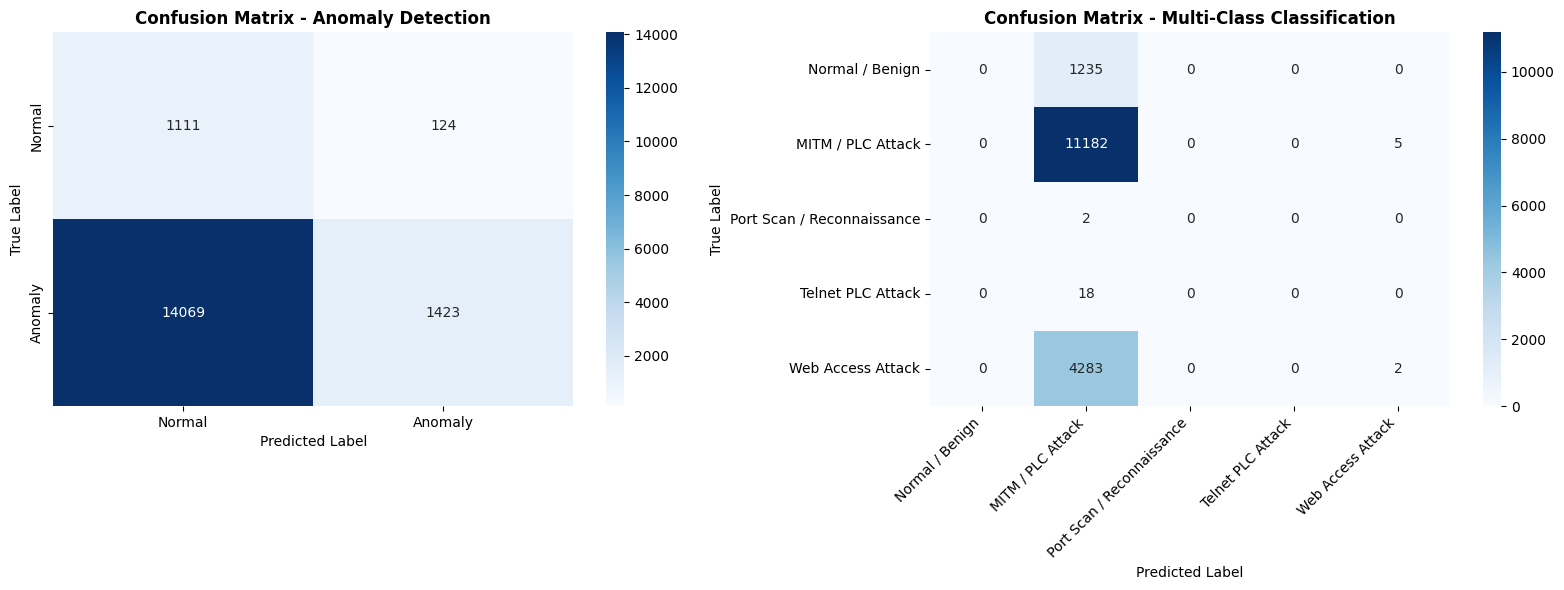

Saved: autoencoder_training_loss_hybrid.png


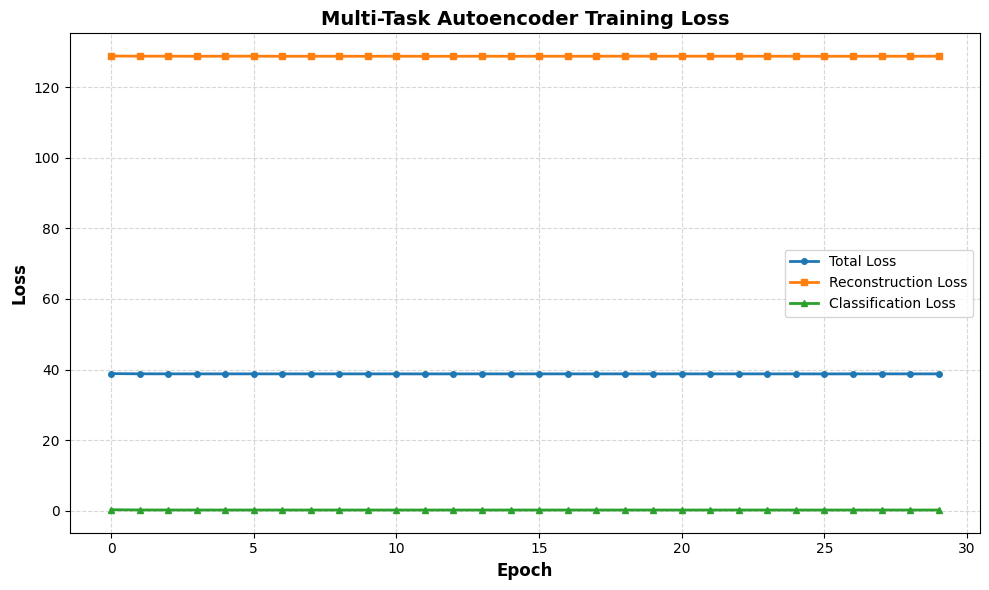


----------------------------------------------------------------------
TRAINING XGBOOST ON LATENT SPACE
----------------------------------------------------------------------
Extracting latent features from autoencoder...
Latent train shape: (223835, 32)
Latent test shape: (16727, 32)

Training XGBoost on latent features...
XGBoost on latent space trained successfully

----------------------------------------------------------------------
XGBOOST ON LATENT SPACE - PERFORMANCE METRICS
----------------------------------------------------------------------
                            precision    recall  f1-score   support

           Normal / Benign       0.00      0.00      0.00      1235
         MITM / PLC Attack       0.67      1.00      0.80     11187
Port Scan / Reconnaissance       0.00      0.00      0.00         2
         Telnet PLC Attack       0.00      0.00      0.00        18
         Web Access Attack       0.25      0.00      0.00      4285

                  accuracy   

In [30]:
print("\n" + "="*70)
print("SECTION 4: HYBRID MULTI-TASK LSTM-AUTOENCODER TRAINING")
print("="*70)

# Use ALL training data (normal + attacks) for multi-task learning
print(f"\nTraining on ALL data: {X_train_DL.shape[0]} sequences")
print(f"Sequence shape: {X_train_DL.shape[1:]}")
print(f"Number of classes: {len(np.unique(y_train_DL))}")

class MultiTaskLSTMAutoencoder(nn.Module):
    """
    Hybrid Multi-Task LSTM Autoencoder:
    - Reconstruction branch: Anomaly detection (MSE loss)
    - Classification branch: Attack type classification (Cross-Entropy loss)
    - Shared encoder: Learns features useful for both tasks
    
    FIX: Added Tanh output activation to constrain reconstruction to [-1, 1]
    """
    def __init__(self, seq_len, num_features, latent_dim, num_classes, hidden_dim=128):
        super(MultiTaskLSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.num_features = num_features
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Encoder - with more capacity
        self.encoder_lstm1 = nn.LSTM(num_features, hidden_dim, batch_first=True, bidirectional=True)
        self.encoder_lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim * 2, batch_first=True)
        
        # Project to latent space
        self.latent_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, latent_dim),
            nn.ReLU()
        )
        
        # Decoder
        self.decoder_lstm1 = nn.LSTM(latent_dim, hidden_dim * 2, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True)
        
        # FIX: Add Tanh activation to constrain output to [-1, 1]
        # This prevents the reconstruction loss from exploding
        self.decoder_proj = nn.Sequential(
            nn.Linear(hidden_dim, num_features),
            nn.Tanh()  # Output range: [-1, 1]
        )
        
        # Classifier - deeper network
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Encoder
        encoder_out1, _ = self.encoder_lstm1(x)  # (batch, seq, hidden*2)
        encoder_out2, (hidden, cell) = self.encoder_lstm2(encoder_out1)
        
        # Use last hidden state
        last_hidden = encoder_out2[:, -1, :]  # (batch, hidden*2)
        
        # Project to latent
        latent = self.latent_proj(last_hidden)  # (batch, latent_dim)
        
        # Decoder
        latent_seq = latent.unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_out1, _ = self.decoder_lstm1(latent_seq)
        decoder_out2, _ = self.decoder_lstm2(decoder_out1)
        
        # FIX: Apply Tanh activation to output
        recon = self.decoder_proj(decoder_out2)
        
        # Classifier
        class_logits = self.classifier(latent)
        
        return recon, class_logits
    
    def encode(self, x):
        """Extract latent representation"""
        encoder_out1, _ = self.encoder_lstm1(x)
        encoder_out2, (hidden, cell) = self.encoder_lstm2(encoder_out1)
        last_hidden = encoder_out2[:, -1, :]
        return self.latent_proj(last_hidden)
    
    def get_reconstruction(self, x):
        """Get reconstruction only (for anomaly detection)."""
        recon, _ = self.forward(x)
        return recon
    
    def get_classification(self, x):
        """Get classification logits only."""
        _, logits = self.forward(x)
        return logits

# ====================================================================
# FIXED: Use actual data shapes with Tanh-compatible parameters
# ====================================================================
seq_len = X_train_DL.shape[1]
num_features = X_train_DL.shape[2]
num_classes = len(np.unique(y_train_DL))
latent_dim = 32
hidden_dim = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
print(f"Sequence length: {seq_len}, Features: {num_features}")
print(f"Latent dimension: {latent_dim}, Hidden dimension: {hidden_dim}")
print(f"Number of classes: {num_classes}")

# Initialize model with the correct dimensions
autoencoder = MultiTaskLSTMAutoencoder(
    seq_len=seq_len,
    num_features=num_features,
    latent_dim=latent_dim,
    num_classes=num_classes,
    hidden_dim=hidden_dim
).to(device)

# FIX: Use Huber Loss (Smooth L1) which is more robust to outliers
# This prevents the loss from exploding
reconstruction_criterion = nn.SmoothL1Loss()  # More robust than MSELoss
classification_criterion = nn.CrossEntropyLoss()

# Optimizer with weight decay for regularization
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)

# Prepare DataLoaders with ALL data (normal + attacks)
train_tensor = torch.tensor(X_train_DL, dtype=torch.float32)
train_labels = torch.tensor(y_train_DL, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(train_tensor, train_labels), 
    batch_size=64, 
    shuffle=True
)

test_tensor = torch.tensor(X_test_DL, dtype=torch.float32)
test_labels = torch.tensor(y_test_DL, dtype=torch.long)

test_loader = DataLoader(
    TensorDataset(test_tensor, test_labels), 
    batch_size=64, 
    shuffle=False
)

# Training configuration
EPOCHS = 30
ALPHA = 0.3
THRESHOLD_PERCENTILE = 90

print(f"\nTraining for {EPOCHS} epochs...")
print("-"*70)
print(f"Loss weighting (α): {ALPHA} (Reconstruction), {1-ALPHA} (Classification)")
print(f"Reconstruction Loss: Smooth L1 Loss (robust to outliers)")
print(f"Output Activation: Tanh (range: [-1, 1])")
print("-"*70)

# Training loop
autoencoder.train()
train_losses = []
recon_losses = []
class_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    epoch_recon_loss = 0.0
    epoch_class_loss = 0.0
    batch_count = 0
    
    for batch in train_loader:
        inputs, labels = batch[0].to(device), batch[1].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass through both branches
        reconstructions, class_logits = autoencoder(inputs)
        
        # Reconstruction loss (Smooth L1 Loss - robust to outliers)
        loss_recon = reconstruction_criterion(reconstructions, inputs)
        
        # Classification loss (Cross-Entropy)
        loss_class = classification_criterion(class_logits, labels)
        
        # Combined loss with weighting
        total_loss = (ALPHA * loss_recon) + ((1 - ALPHA) * loss_class)
        
        total_loss.backward()
        
        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += total_loss.item()
        epoch_recon_loss += loss_recon.item()
        epoch_class_loss += loss_class.item()
        batch_count += 1
    
    avg_loss = epoch_loss / batch_count
    avg_recon_loss = epoch_recon_loss / batch_count
    avg_class_loss = epoch_class_loss / batch_count
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon_loss)
    class_losses.append(avg_class_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]")
        print(f"  Total Loss: {avg_loss:.6f}")
        print(f"  Recon Loss: {avg_recon_loss:.6f}")
        print(f"  Class Loss: {avg_class_loss:.6f}")

print("\n✅ Multi-Task Autoencoder training completed")

# ====================================================================
# EVALUATION: Both Anomaly Detection + Multi-Class Classification
# ====================================================================

print("\n" + "="*70)
print("EVALUATION PHASE")
print("="*70)

autoencoder.eval()
all_recon_errors = []
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        test_inputs = batch[0].to(device)
        test_labels = batch[1].to(device)
        
        reconstructions, class_logits = autoencoder(test_inputs)
        
        # 1. Reconstruction error (for anomaly detection)
        # Use MSE for anomaly detection (even though training used Smooth L1)
        batch_errors = (
            torch.mean((reconstructions - test_inputs) ** 2, dim=(1, 2))
            .cpu()
            .numpy()
        )
        all_recon_errors.extend(batch_errors)
        
        # 2. Class predictions (for attack classification)
        preds = torch.argmax(class_logits, dim=1).cpu().numpy()
        all_predictions.extend(preds)
        all_true_labels.extend(test_labels.cpu().numpy())

all_recon_errors = np.array(all_recon_errors)
all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# ====================================================================
# PART 1: ANOMALY DETECTION PERFORMANCE
# ====================================================================

print("\n" + "-"*70)
print("PART 1: ANOMALY DETECTION PERFORMANCE")
print("-"*70)

# Calculate threshold from normal traffic only
normal_recon_errors = all_recon_errors[all_true_labels == 0]

if len(normal_recon_errors) > 0:
    threshold = np.percentile(normal_recon_errors, THRESHOLD_PERCENTILE)
    print(f"Normal traffic reconstruction error statistics:")
    print(f"  Min: {normal_recon_errors.min():.6f}")
    print(f"  Max: {normal_recon_errors.max():.6f}")
    print(f"  Mean: {normal_recon_errors.mean():.6f}")
    print(f"  Std: {normal_recon_errors.std():.6f}")
else:
    threshold = np.percentile(all_recon_errors, THRESHOLD_PERCENTILE)
    print(f"⚠ Warning: No normal samples found in test set.")
    print(f"Using global {THRESHOLD_PERCENTILE}th percentile: {threshold:.6f}")

print(f"\nAnomaly Detection Threshold ({THRESHOLD_PERCENTILE}th percentile): {threshold:.6f}")

# Binary prediction for anomaly detection
y_pred_anomaly = np.where(all_recon_errors > threshold, 1, 0)
y_true_binary = np.where(all_true_labels > 0, 1, 0)

print("\nANOMALY DETECTION METRICS:")
print(classification_report(
    y_true_binary, 
    y_pred_anomaly, 
    target_names=["Normal", "Anomaly"],
    zero_division=0
))

# Anomaly detection metrics
f1_anomaly = f1_score(y_true_binary, y_pred_anomaly, average="weighted", zero_division=0)
precision_anomaly = precision_score(y_true_binary, y_pred_anomaly, zero_division=0)
recall_anomaly = recall_score(y_true_binary, y_pred_anomaly, zero_division=0)
roc_auc_anomaly = roc_auc_score(y_true_binary, all_recon_errors)

print(f"\nWeighted F1-Score: {f1_anomaly:.4f}")
print(f"Precision (Anomaly class): {precision_anomaly:.4f}")
print(f"Recall (Anomaly class): {recall_anomaly:.4f}")
print(f"ROC-AUC Score: {roc_auc_anomaly:.4f}")

# ====================================================================
# PART 2: MULTI-CLASS CLASSIFICATION PERFORMANCE
# ====================================================================

print("\n" + "-"*70)
print("PART 2: MULTI-CLASS ATTACK CLASSIFICATION PERFORMANCE")
print("-"*70)

print("CLASSIFICATION REPORT:")
print(classification_report(
    all_true_labels, 
    all_predictions, 
    target_names=class_names,
    zero_division=0
))

# Per-class metrics
f1_multi = f1_score(all_true_labels, all_predictions, average="weighted", zero_division=0)
precision_multi = precision_score(all_true_labels, all_predictions, average="weighted", zero_division=0)
recall_multi = recall_score(all_true_labels, all_predictions, average="weighted", zero_division=0)

print(f"\nWeighted F1-Score: {f1_multi:.4f}")
print(f"Precision: {precision_multi:.4f}")
print(f"Recall: {recall_multi:.4f}")

# Per-class detailed performance
print("\n" + "-"*70)
print("PER-CLASS PERFORMANCE BREAKDOWN")
print("-"*70)
for i, name in enumerate(class_names):
    tp = np.sum((all_true_labels == i) & (all_predictions == i))
    fp = np.sum((all_true_labels != i) & (all_predictions == i))
    fn = np.sum((all_true_labels == i) & (all_predictions != i))
    
    precision_i = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_i = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_i = 2 * precision_i * recall_i / (precision_i + recall_i) if (precision_i + recall_i) > 0 else 0
    
    print(f"  {name}:")
    print(f"    Precision: {precision_i:.4f}, Recall: {recall_i:.4f}, F1: {f1_i:.4f}")

# ====================================================================
# PART 3: RECONSTRUCTION ERROR BY CLASS
# ====================================================================

print("\n" + "-"*70)
print("RECONSTRUCTION ERROR BY CLASS")
print("-"*70)
for class_id in np.unique(all_true_labels):
    class_errors = all_recon_errors[all_true_labels == class_id]
    if len(class_errors) > 0:
        class_name = ATTACK_TYPES.get(class_id, f"Class_{class_id}")
        print(f"  {class_name}:")
        print(f"    Mean: {class_errors.mean():.6f} ± {class_errors.std():.6f}")
        print(f"    Min: {class_errors.min():.6f}, Max: {class_errors.max():.6f}")

# ====================================================================
# PART 4: CONFUSION MATRIX VISUALIZATION
# ====================================================================

print("\n" + "-"*70)
print("CONFUSION MATRIX VISUALIZATION")
print("-"*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix 1: Anomaly Detection (Binary)
cm_anomaly = confusion_matrix(y_true_binary, y_pred_anomaly)
sns.heatmap(cm_anomaly, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"],
            cbar=True)
axes[0].set_title("Confusion Matrix - Anomaly Detection", fontsize=12, fontweight='bold')
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# Confusion Matrix 2: Multi-Class Classification
cm_multi = confusion_matrix(all_true_labels, all_predictions)
sns.heatmap(cm_multi, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            cbar=True)
axes[1].set_title("Confusion Matrix - Multi-Class Classification", fontsize=12, fontweight='bold')
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrices_hybrid.png", dpi=100, bbox_inches='tight')
print("Saved: confusion_matrices_hybrid.png")
plt.show()

# ====================================================================
# PART 5: TRAINING LOSS CURVE
# ====================================================================

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, linewidth=2, color='#1f77b4', marker='o', markersize=4, label='Total Loss')
ax.plot(recon_losses, linewidth=2, color='#ff7f0e', marker='s', markersize=4, label='Reconstruction Loss')
ax.plot(class_losses, linewidth=2, color='#2ca02c', marker='^', markersize=4, label='Classification Loss')

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Multi-Task Autoencoder Training Loss', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("autoencoder_training_loss_hybrid.png", dpi=100, bbox_inches='tight')
print("Saved: autoencoder_training_loss_hybrid.png")
plt.show()

# Store autoencoder metrics for later use
f1_ae = f1_anomaly
precision_ae = precision_anomaly
recall_ae = recall_anomaly
y_pred_ae = y_pred_anomaly

# ====================================================================
# NEW: TRAIN XGBOOST ON LATENT SPACE
# ====================================================================

print("\n" + "-"*70)
print("TRAINING XGBOOST ON LATENT SPACE")
print("-"*70)

# Extract latent representations from the autoencoder
print("Extracting latent features from autoencoder...")
autoencoder.eval()
with torch.no_grad():
    # Convert to tensor
    X_train_tensor = torch.tensor(X_train_DL, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_DL, dtype=torch.float32)
    
    # Encode to latent space
    latent_train = autoencoder.encode(X_train_tensor).cpu().numpy()
    latent_test = autoencoder.encode(X_test_tensor).cpu().numpy()

print(f"Latent train shape: {latent_train.shape}")
print(f"Latent test shape: {latent_test.shape}")

# Train XGBoost on latent features
xgb_latent = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,  # Shallower to prevent overfitting
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=num_classes,
    tree_method="hist",
    n_jobs=-1
)

print("\nTraining XGBoost on latent features...")
xgb_latent.fit(
    latent_train, y_train_DL,
    eval_set=[(latent_test, y_test_DL)],
    verbose=False
)
print("XGBoost on latent space trained successfully")

# Evaluate XGBoost on latent space
y_pred_latent = xgb_latent.predict(latent_test)
y_pred_latent_proba = xgb_latent.predict_proba(latent_test)

print("\n" + "-"*70)
print("XGBOOST ON LATENT SPACE - PERFORMANCE METRICS")
print("-"*70)
print(classification_report(
    y_test_DL, 
    y_pred_latent, 
    target_names=class_names,
    zero_division=0
))

f1_latent = f1_score(y_test_DL, y_pred_latent, average="weighted", zero_division=0)
precision_latent = precision_score(y_test_DL, y_pred_latent, average="weighted", zero_division=0)
recall_latent = recall_score(y_test_DL, y_pred_latent, average="weighted", zero_division=0)

print(f"\nWeighted F1-Score: {f1_latent:.4f}")
print(f"Precision: {precision_latent:.4f}")
print(f"Recall: {recall_latent:.4f}")

# Save latent XGBoost model
joblib.dump(xgb_latent, "../outputs/xgboost_latent_model.pkl")
print("\nSaved: ../outputs/xgboost_latent_model.pkl")

**Increased hidden_dim :** 256 neurons

Each neuron does: (256 inputs × 4 gates) = 1,024 multiplications


Total per time step: 1,024 × 256 = 262,144 operations
Result: 4× more operations!

**Increased latent_dim :** 

Original: 16 → 16 × (dense_layer) = 16 × 128 = 2,048 weights

Increased: 64 → 64 × 256 = 16,384 weights

Result: 8× more weights to learn!

#### SECTION 5: MODEL COMPARISON & VISUALIZATION


SECTION 5: MODEL COMPARISON & ANALYSIS
MODEL PERFORMANCE COMPARISON
----------------------------------------------------------------------
                 Model  Precision   Recall  F1-Score                         Type
      Isolation Forest   0.991556 1.000000  0.991908                 Unsupervised
               XGBoost   0.909290 0.905897  0.907049     Supervised (Multi-Class)
XGBoost (Latent Space)   0.511296 0.668440  0.536221 Supervised (Latent Features)
      LSTM-Autoencoder   0.919845 0.091854  0.164691            Unsupervised (DL)

Best performing model: Isolation Forest (F1=0.9919)

Saved: confusion_matrices.png


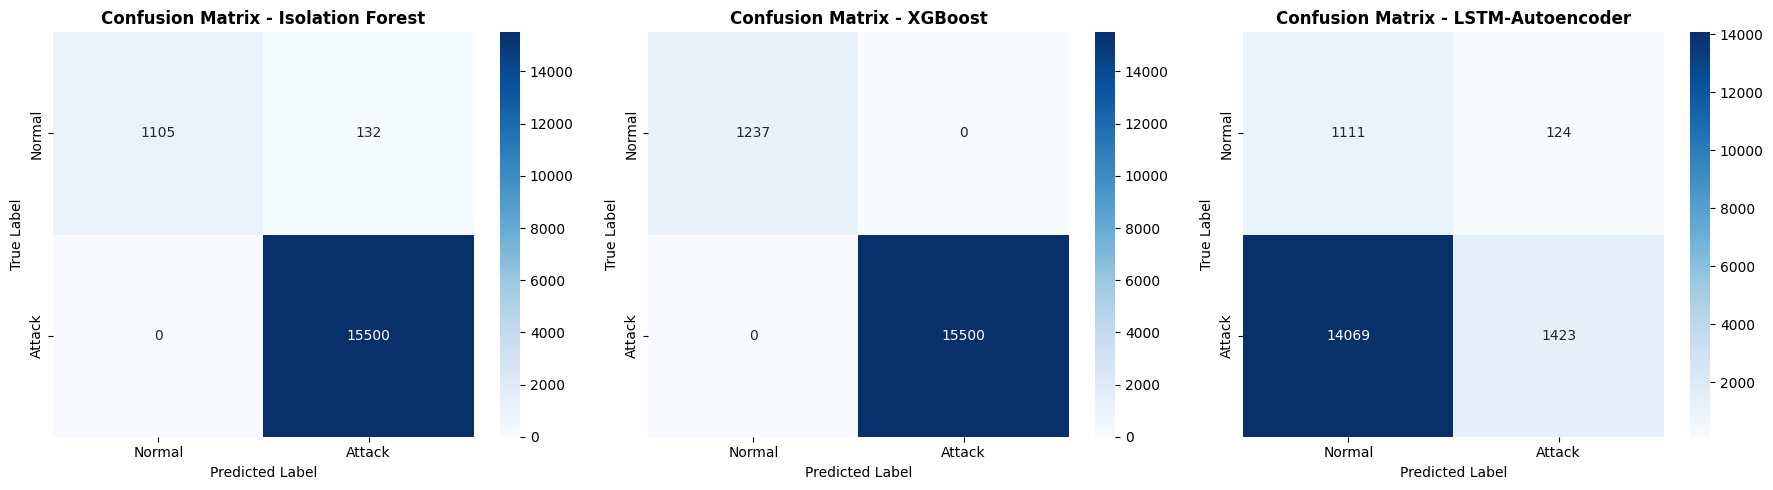

Saved: f1_score_comparison.png


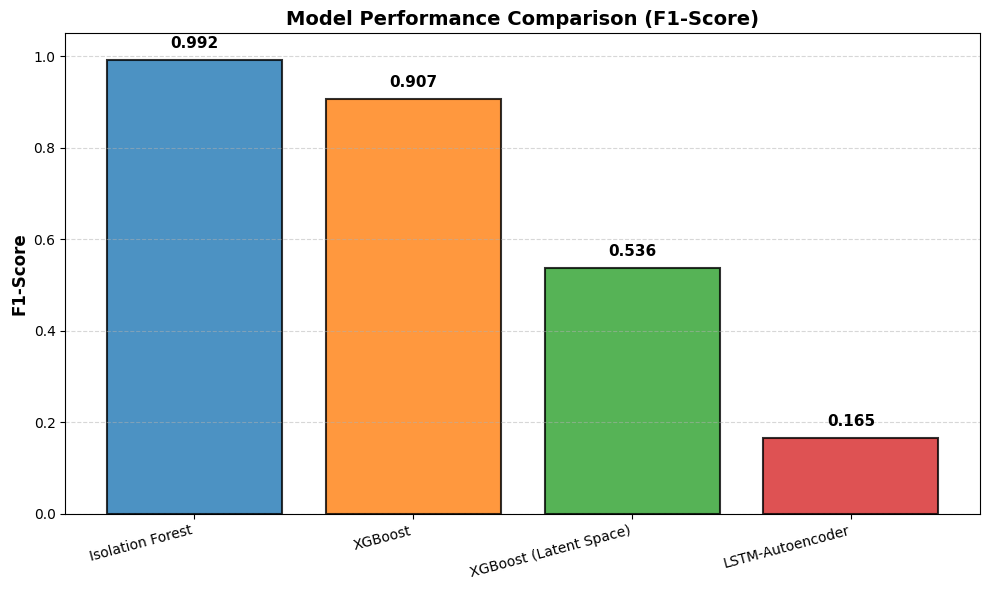

Saved: feature_importance.png


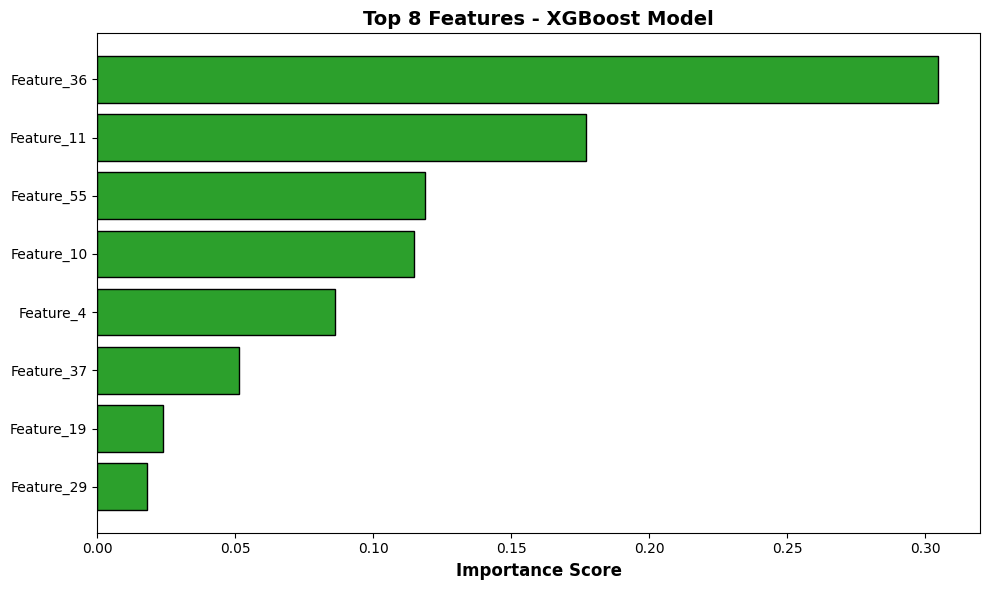

Saved: autoencoder_training_loss.png


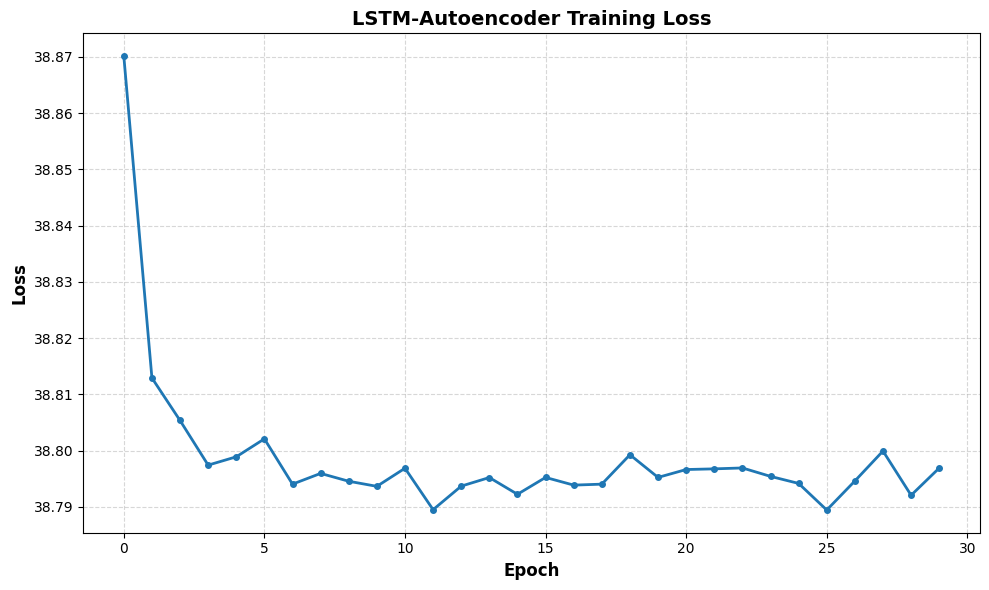

In [31]:
print("\n" + "="*70)
print("SECTION 5: MODEL COMPARISON & ANALYSIS")
print("="*70)

# Performance comparison table
comparison_data = {
    'Model': ['Isolation Forest', 'XGBoost','XGBoost (Latent Space)', 'LSTM-Autoencoder'],
    'Precision': [precision_if, precision_xgb,precision_latent, precision_ae],
    'Recall': [recall_if, recall_xgb, recall_latent, recall_ae],
    'F1-Score': [f1_if, f1_xgb, f1_latent, f1_ae],
    'Type': ['Unsupervised', 'Supervised (Multi-Class)', 'Supervised (Latent Features)', 'Unsupervised (DL)']
}

df_comparison = pd.DataFrame(comparison_data)

print("MODEL PERFORMANCE COMPARISON")
print("-"*70)
print(df_comparison.to_string(index=False))

# Determine best performing model
best_model_idx = df_comparison['F1-Score'].idxmax()
best_model_name = df_comparison.loc[best_model_idx, 'Model']
best_f1 = df_comparison.loc[best_model_idx, 'F1-Score']

print(f"\nBest performing model: {best_model_name} (F1={best_f1:.4f})")

# Confusion matrices visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use binary labels for fair comparison
y_test_binary = np.where(y_test_ML > 0, 1, 0)

models_data = [
    ("Isolation Forest", y_test_binary, y_pred_if_binary),
    ("XGBoost", y_test_binary, np.where(y_pred_xgb > 0, 1, 0)),
    ("LSTM-Autoencoder", y_true_binary, y_pred_anomaly)
]

for idx, (name, y_true, y_pred) in enumerate(models_data):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"],
                cbar=True)
    axes[idx].set_title(f"Confusion Matrix - {name}", fontsize=12, fontweight='bold')
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=100, bbox_inches='tight')
print("\nSaved: confusion_matrices.png")
plt.show()

# F1-Score comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))
models = df_comparison['Model']
f1_scores = df_comparison['F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (F1-Score)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("f1_score_comparison.png", dpi=100, bbox_inches='tight')
print("Saved: f1_score_comparison.png")
plt.show()

# Feature importance visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(8)
ax.barh(range(len(top_features)), top_features['importance'].values, color='#2ca02c', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 8 Features - XGBoost Model', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100, bbox_inches='tight')
print("Saved: feature_importance.png")
plt.show()

# Training loss curve for LSTM-Autoencoder
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, linewidth=2, color='#1f77b4', marker='o', markersize=4)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('LSTM-Autoencoder Training Loss', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("autoencoder_training_loss.png", dpi=100, bbox_inches='tight')
print("Saved: autoencoder_training_loss.png")
plt.show()

#### SECTION 6: SAVE TRAINED MODELS

In [32]:
print("\n" + "="*70)
print("SECTION 6: SAVING TRAINED MODELS")
print("="*70)

# Create outputs directory if it doesn't exist
os.makedirs("../outputs", exist_ok=True)

# Save ML models
joblib.dump(iso_forest, "../outputs/isolation_forest.pkl")
joblib.dump(xgb_model, "../outputs/xgboost_model.pkl")
print("\nSaved ML models:")
print("  - ../outputs/isolation_forest.pkl")
print("  - ../outputs/xgboost_model.pkl")

# Save LSTM-Autoencoder
torch.save(autoencoder.state_dict(), "../outputs/lstm_autoencoder.pt")
print("  - ../outputs/lstm_autoencoder.pt")

# Save full model configuration
model_config = {
    'seq_len': seq_len,
    'num_features': num_features,
    'threshold': float(threshold),
    'threshold_percentile': THRESHOLD_PERCENTILE,
    'hidden_dim': 64,
    'latent_dim': 16,
    'num_classes': num_classes,
    'class_names': class_names,
    'attack_types': ATTACK_TYPES,
    'alpha': ALPHA
}

with open("../outputs/model_config.json", 'w') as f:
    json.dump(model_config, f, indent=2)

print("  - ../outputs/model_config.json")

# Save performance summary
df_comparison.to_csv("../outputs/model_comparison.csv", index=False)
print("  - ../outputs/model_comparison.csv")

# Save class mapping for admin dashboard
class_mapping_df = pd.DataFrame({
    'Class_ID': list(range(num_classes)),
    'Attack_Type': class_names
})
class_mapping_df.to_csv("../outputs/class_mapping.csv", index=False)
print("  - ../outputs/class_mapping.csv")

print("\n" + "="*70)
print("MODEL TRAINING COMPLETE")
print("="*70)
print("\n✅ Models trained and saved successfully!")
print("\nAttack Types Detected:")
for i, name in enumerate(class_names):
    print(f"  Class {i}: {name}")

print("\nNext step: Run Notebook 3 for cross-dataset evaluation.")


SECTION 6: SAVING TRAINED MODELS

Saved ML models:
  - ../outputs/isolation_forest.pkl
  - ../outputs/xgboost_model.pkl
  - ../outputs/lstm_autoencoder.pt
  - ../outputs/model_config.json
  - ../outputs/model_comparison.csv
  - ../outputs/class_mapping.csv

MODEL TRAINING COMPLETE

✅ Models trained and saved successfully!

Attack Types Detected:
  Class 0: Normal / Benign
  Class 1: MITM / PLC Attack
  Class 2: Port Scan / Reconnaissance
  Class 3: Telnet PLC Attack
  Class 4: Web Access Attack

Next step: Run Notebook 3 for cross-dataset evaluation.
